# Blocco 0: Importazioni e setup ambiente
- importazione delle librerie necessarie:
1. TensorFlow/Keras, 
2. Pandas, 
3. NumPy, 
4. Matplotlib, 
5. Scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Impostiamo il seed di riproducibilità

np.random.seed(42)
tf.random.set_seed(42)


### Blocco 1: Caricamento, filtraggio e pre-elaborazione del DatasetAssicurati di avere i file sign_mnist_train.csv e sign_mnist_test.csv nella stessa cartella del notebook (o aggiorna i percorsi).

- In questo step:
1. Carichiamo train e test set da CSV.
2. Filtriamo per le prime 5 classi (A=0, B=1, C=2, D=3, E=4).
3. Normalizziamo i pixel nell'intervallo $[0, 1]$.
4. Eseguiamo uno split di validation sul train set ($80%$ train, $20%$ validation)

In [3]:
# 1 Caricahimo file CSV
train_df = pd.read_csv('sign_mnist_train.csv')
test_df = pd.read_csv('sign_mnist_test.csv')

# 2 FIltraggio: consideriamo solo le prime 5 classi (0=A, 1=B, 2=C, 3=D, 4=E)

# crea una copia della 5 classi pulita in memoria
train_filtred = train_df[train_df['label'] < 5].copy()
test_filtred = test_df[test_df['label'] < 5].copy()

# Separazione target (label) e feature (pixel)
X_train_raw =  train_filtred.drop(columns=['label']).values
y_train_raw = train_filtred['label'].values

X_test_raw = test_filtred.drop(columns=['label']).values
y_test = test_filtred['label'].values

# 3 Normalizzazione [0, 1]

X_train_norm = X_train_raw / 255.0
X_test = X_test_norm = X_test_raw / 255.0

# 4. Train-Validation Split (80% train, 20% validation)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_norm, y_train_raw, test_size=0.02, random_state=42, stratify=y_train_raw
    )

print(f"Dimensioni Addestramento: {X_train.shape}, Etichette Addestramento: {y_train.shape}")
print(f"Dimensioni Validazione: {X_val.shape}, Etichette Validazione: {y_val.shape}")
print(f"Dimensioni Test: {X_test.shape}, Etichette Test: {y_test.shape}")

Dimensioni Addestramento: (5324, 784), Etichette Addestramento: (5324,)
Dimensioni Validazione: (109, 784), Etichette Validazione: (109,)
Dimensioni Test: (1816, 784), Etichette Test: (1816,)


### locco 2: Progettazione e addestramento ANN (Artificial Neural Network)

- Per l'ANN testiamo 3 configurazioni con diverse tecniche di regolarizzazione (Dropout, L2, Early Stopping) e ottimizzatore Adam (scelto per la sua convergenza rapida ed stabilità sui gradienti grazie ai momenti di primo e secondo ordine).

In [4]:
# --- CONFIGURAZIONE 1: Rete Profonda con Batch Normalization e Dropout ---
ann_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(5, activation='softmax')
])

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann_1 = ann_model.fit(
    X_train, y_train, 
    epochs=20, 
    batch_size=64, 
    validation_data=(X_val, y_val)
)

# Salva il modello e la miglior accuracy di validation
best_ann_model_1 = ann_model
val_acc_1 = max(history_ann_1.history['val_accuracy'])
print(f"\nAccuratezza Validazione Configurazione 1: {val_acc_1:.4f}")

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9005 - loss: 0.2947 - val_accuracy: 0.9450 - val_loss: 0.4694
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9833 - loss: 0.0573 - val_accuracy: 0.8807 - val_loss: 0.3319
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9899 - loss: 0.0379 - val_accuracy: 0.7064 - val_loss: 0.8387
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9863 - loss: 0.0387 - val_accuracy: 0.6881 - val_loss: 0.8499
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9842 - loss: 0.0460 - val_accuracy: 0.8899 - val_loss: 0.2283
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9840 - loss: 0.0429 - val_accuracy: 0.8716 - val_loss: 0.4426
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9572 - loss: 0.1231 - val_accuracy: 0.4312 - val_loss: 4.3169
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9570 - loss: 0.1170 - val_accuracy: 0.7615 - val_loss:

### Metriche tramite grafico

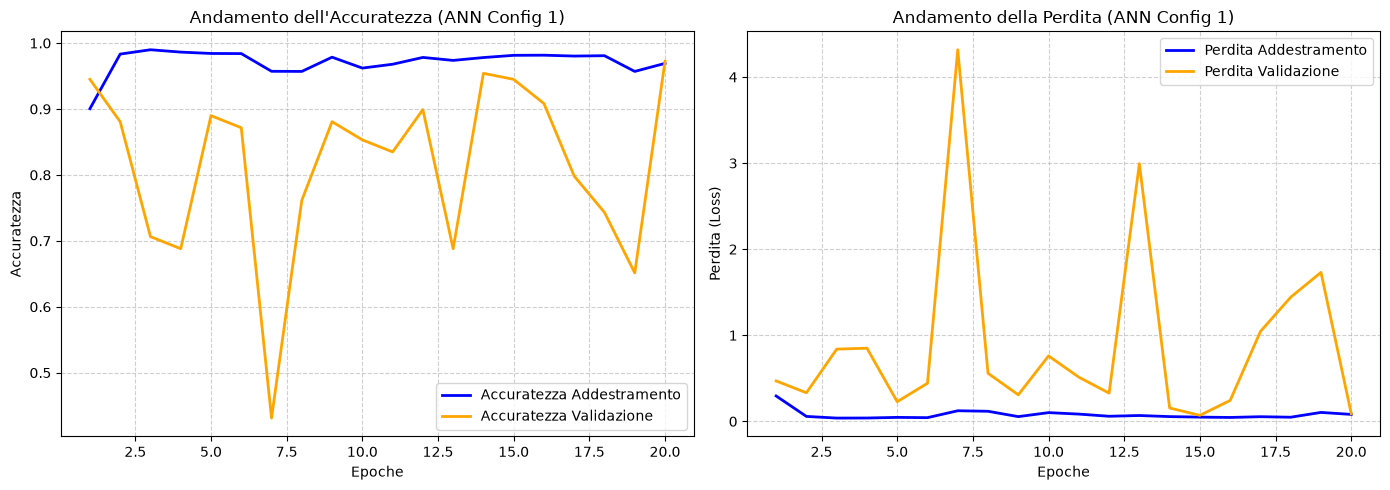

In [5]:
import matplotlib.pyplot as plt

# Estrazione dei dati di accuratezza e loss dalla storia dell'addestramento
acc = history_ann_1.history['accuracy']
val_acc = history_ann_1.history['val_accuracy']
loss = history_ann_1.history['loss']
val_loss = history_ann_1.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Creazione della figura con due grafici affiancati
plt.figure(figsize=(14, 5))

# Grafico 1: Accuratezza (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Accuratezza Addestramento', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Accuratezza Validazione', color='orange', linewidth=2)
plt.title('Andamento dell\'Accuratezza (ANN Config 1)', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Grafico 2: Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Perdita Addestramento', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Perdita Validazione', color='orange', linewidth=2)
plt.title('Andamento della Perdita (ANN Config 1)', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('Perdita (Loss)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Configurazione 2: Rete Media con Regolarizzazione L2

In [6]:
# --- CONFIGURAZIONE 2: Rete Media con Regolarizzazione L2 e Dropout ---
ann_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(5, activation='softmax')
])

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann_2 = ann_model.fit(
    X_train, y_train, 
    epochs=20, 
    batch_size=64, 
    validation_data=(X_val, y_val)
)

# Salva il modello e la miglior accuracy di validation
best_ann_model_2 = ann_model
val_acc_2 = max(history_ann_2.history['val_accuracy'])
print(f"\nAccuratezza Validazione Configurazione 2: {val_acc_2:.4f}")

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6249 - loss: 1.3501 - val_accuracy: 0.9450 - val_loss: 0.6492
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9172 - loss: 0.5858 - val_accuracy: 0.9817 - val_loss: 0.3848
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9716 - loss: 0.3825 - val_accuracy: 1.0000 - val_loss: 0.2899
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9810 - loss: 0.3196 - val_accuracy: 1.0000 - val_loss: 0.2573
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9902 - loss: 0.2700 - val_accuracy: 1.0000 - val_loss: 0.2238
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9925 - loss: 0.2439 - val_accuracy: 1.0000 - val_loss: 0.2064
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9959 - loss: 0.2163 - val_accuracy: 1.0000 - val_loss: 0.1916
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9822 - loss: 0.2389 - val_accuracy: 1.0000 - val_loss:

### Grafico metriche

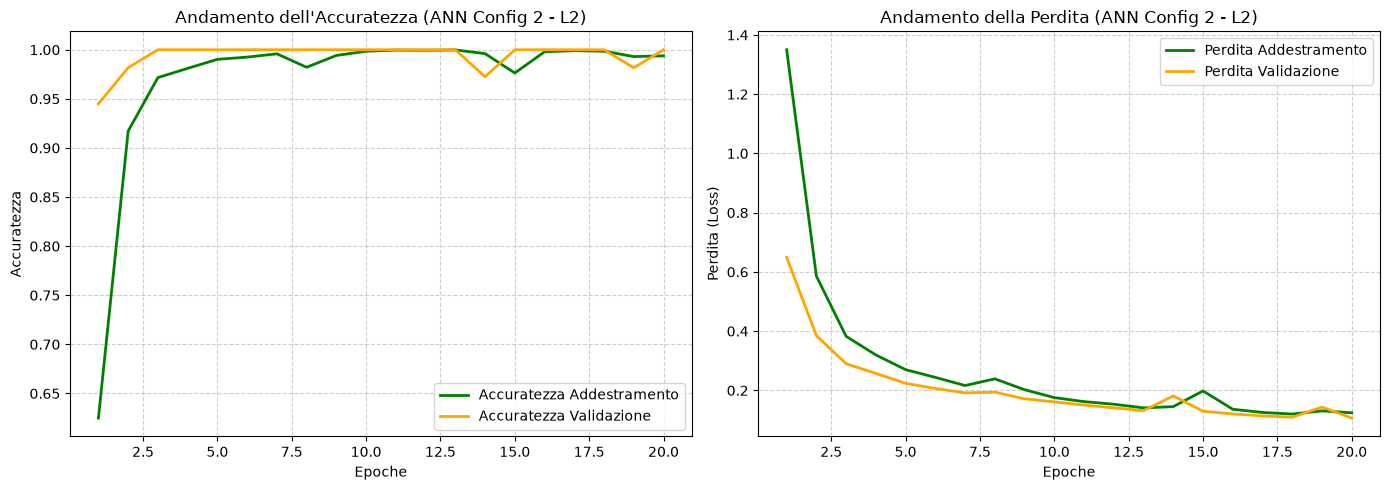

In [7]:
import matplotlib.pyplot as plt

# Estrazione dei dati dalla storia dell'addestramento della Configurazione 2
acc_2 = history_ann_2.history['accuracy']
val_acc_2_list = history_ann_2.history['val_accuracy']
loss_2 = history_ann_2.history['loss']
val_loss_2 = history_ann_2.history['val_loss']

epochs_range = range(1, len(acc_2) + 1)

# Creazione della figura con due grafici affiancati
plt.figure(figsize=(14, 5))

# Grafico 1: Accuratezza (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_2, label='Accuratezza Addestramento', color='green', linewidth=2)
plt.plot(epochs_range, val_acc_2_list, label='Accuratezza Validazione', color='orange', linewidth=2)
plt.title('Andamento dell\'Accuratezza (ANN Config 2 - L2)', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Grafico 2: Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_2, label='Perdita Addestramento', color='green', linewidth=2)
plt.plot(epochs_range, val_loss_2, label='Perdita Validazione', color='orange', linewidth=2)
plt.title('Andamento della Perdita (ANN Config 2 - L2)', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('Perdita (Loss)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [8]:
# --- CONFIGURAZIONE 3: Rete Compatta con Learning Rate ridotto ---
ann_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.1),
    
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    
    tf.keras.layers.Dense(5, activation='softmax')
])

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann_3 = ann_model.fit(
    X_train, y_train, 
    epochs=20, 
    batch_size=64, 
    validation_data=(X_val, y_val)
)

# Salva il modello e la miglior accuracy di validation
best_ann_model_3 = ann_model
val_acc_3 = max(history_ann_3.history['val_accuracy'])
print(f"\nAccuratezza Validazione Configurazione 3: {val_acc_3:.4f}")

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8884 - loss: 0.4185 - val_accuracy: 0.9908 - val_loss: 0.5781
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9964 - loss: 0.0505 - val_accuracy: 1.0000 - val_loss: 0.2261
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9996 - loss: 0.0168 - val_accuracy: 1.0000 - val_loss: 0.0579
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 1.0000 - val_loss: 0.0204
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 1.0000 - val_loss: 0.0064
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 8.2336e-04
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_l

## Grafico Metriche

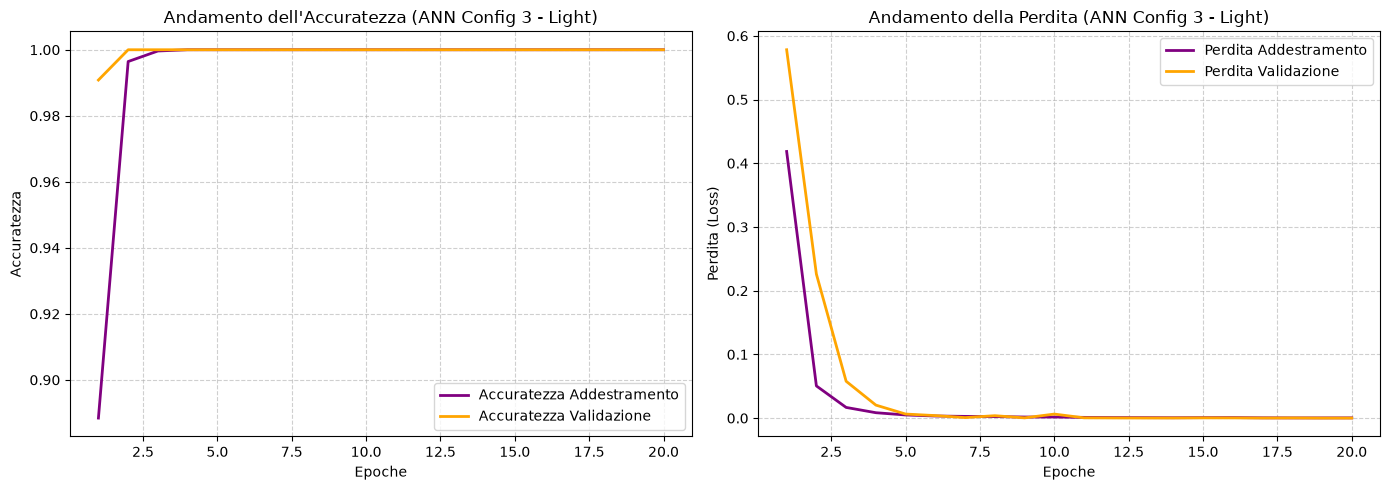

In [9]:
import matplotlib.pyplot as plt

# Estrazione dei dati dalla storia dell'addestramento della Configurazione 3
acc_3 = history_ann_3.history['accuracy']
val_acc_3_list = history_ann_3.history['val_accuracy']
loss_3 = history_ann_3.history['loss']
val_loss_3 = history_ann_3.history['val_loss']

epochs_range = range(1, len(acc_3) + 1)

# Creazione della figura con due grafici affiancati
plt.figure(figsize=(14, 5))

# Grafico 1: Accuratezza (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_3, label='Accuratezza Addestramento', color='purple', linewidth=2)
plt.plot(epochs_range, val_acc_3_list, label='Accuratezza Validazione', color='orange', linewidth=2)
plt.title('Andamento dell\'Accuratezza (ANN Config 3 - Light)', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Grafico 2: Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_3, label='Perdita Addestramento', color='purple', linewidth=2)
plt.plot(epochs_range, val_loss_3, label='Perdita Validazione', color='orange', linewidth=2)
plt.title('Andamento della Perdita (ANN Config 3 - Light)', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('Perdita (Loss)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Blocco 3: Progettazione e addestramento CNN 

- Per la CNN occorre fare il reshape delle immagini da $784$ a $(28, 28, 1)$. Testiamo 3 configurazioni (variando numero di filtri, dimensione dei kernel e regolatori come Batch Normalization e Dropout).

In [16]:
# 1. Reshape dei dati 2D (28, 28, 1)
X_train_img = X_train.reshape(-1, 28, 28, 1)
X_val_img = X_val.reshape(-1, 28, 28, 1)
X_test_img = X_test.reshape(-1, 28, 28, 1)

# Early stopping per evitare overfitting
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

def build_cnn(num_blocks=2, filters_base=32, dropout_rate=0.25):
    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    filters = filters_base

    for i in range(num_blocks):
        model.add(layers.Conv2D(filters, (3, 3), padding='same', activation='relu')) # Corretto Conv2D
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Dropout(dropout_rate))
        filters *= 2 

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3)) # Corretto 0.3
    model.add(layers.Dense(5, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

configurazione_cnn = [
    {'name': 'CNN_Standard (2 blocchi, base 32)', 'blocks': 2, 'filters': 32, 'drop': 0.25},
    {'name': 'CNN_Deep (3 blocchi, base 32)', 'blocks': 3, 'filters': 32, 'drop': 0.30},
    {'name': 'CNN_Light (2 blocchi, base 16)', 'blocks': 2, 'filters': 16, 'drop': 0.20}
]

risultati_cnn = {}

for cfg in configurazione_cnn:
    print(f"\n--- Addestramento {cfg['name']} ---")
    model = build_cnn(num_blocks=cfg['blocks'], filters_base=cfg['filters'], dropout_rate=cfg['drop'])

    history = model.fit(
        X_train_img, y_train,
        validation_data=(X_val_img, y_val),
        epochs=25,
        batch_size=64,
        callbacks=[early_stop],
        verbose=1 # Impostato a 1 per vedere la barra di avanzamento
    )

    val_acc = max(history.history['val_accuracy']) # Corretto history.history
    risultati_cnn[cfg['name']] = (model, history, val_acc) # Corretta l'assegnazione
    print(f"Miglior Val Accuracy per {cfg['name']}: {val_acc:.4f}")

# Selezione miglior CNN (posizionata fuori dal ciclo for)
miglior_cnn_nome = max(risultati_cnn, key=lambda k: risultati_cnn[k][2])
miglior_cnn_modello = risultati_cnn[miglior_cnn_nome][0]
print(f"\n--> Configurazione CNN migliore: {miglior_cnn_nome}")


--- Addestramento CNN_Standard (2 blocchi, base 32) ---
Epoch 1/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8888 - loss: 0.3378 - val_accuracy: 0.4128 - val_loss: 1.3855
Epoch 2/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9944 - loss: 0.0218 - val_accuracy: 0.4862 - val_loss: 1.1883
Epoch 3/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9977 - loss: 0.0100 - val_accuracy: 0.7156 - val_loss: 0.7116
Epoch 4/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9979 - loss: 0.0075 - val_accuracy: 0.9083 - val_loss: 0.2446
Epoch 5/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9977 - loss: 0.0084 - val_accuracy: 0.9817 - val_loss: 0.0682
Epoch 6/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9996 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 7/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 4.4859e-04
Epoch 8/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

## Grarfico Metriche CNN

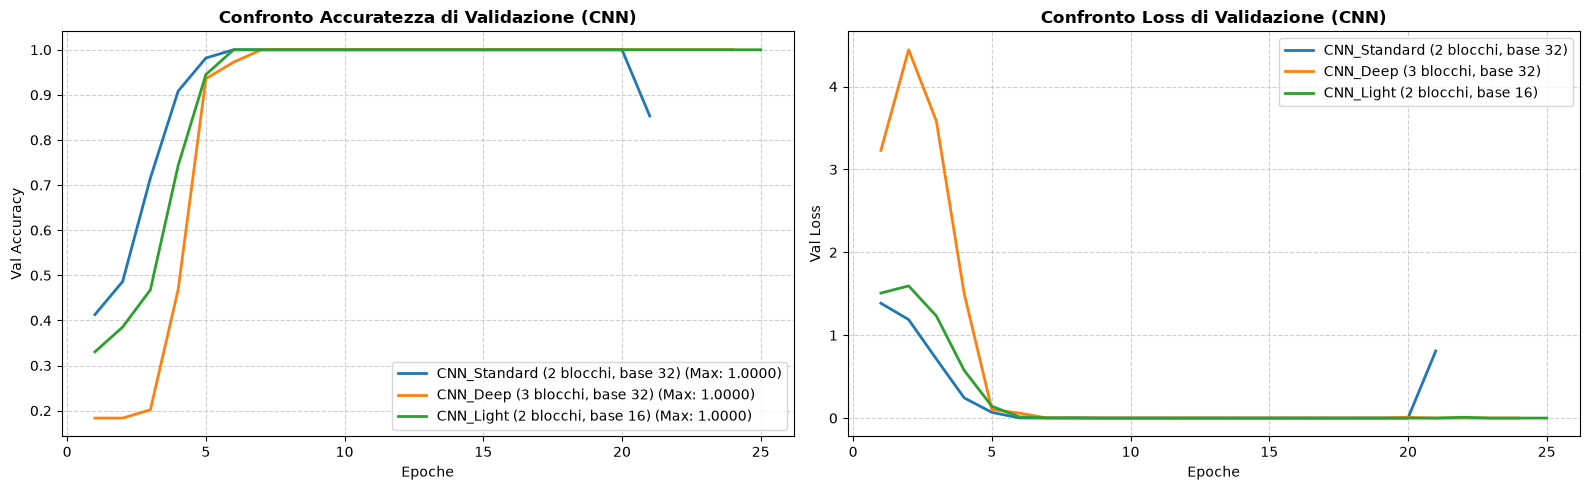

In [17]:
import matplotlib.pyplot as plt

# Definizione dei colori per distinguere chiaramente le 3 configurazioni
colori = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(16, 5))

# --- GRAFICO 1: ACCURATEZZA DI VALIDAZIONE ---
plt.subplot(1, 2, 1)
for (nome, (model, history, val_acc)), colore in zip(risultati_cnn.items(), colori):
    val_accuracy = history.history['val_accuracy']
    epoche = range(1, len(val_accuracy) + 1)
    plt.plot(epoche, val_accuracy, label=f"{nome} (Max: {val_acc:.4f})", color=colore, linewidth=2)

plt.title('Confronto Accuratezza di Validazione (CNN)', fontsize=12, fontweight='bold')
plt.xlabel('Epoche')
plt.ylabel('Val Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- GRAFICO 2: PERDITA (LOSS) DI VALIDAZIONE ---
plt.subplot(1, 2, 2)
for (nome, (model, history, val_acc)), colore in zip(risultati_cnn.items(), colori):
    val_loss = history.history['val_loss']
    epoche = range(1, len(val_loss) + 1)
    plt.plot(epoche, val_loss, label=f"{nome}", color=colore, linewidth=2)

plt.title('Confronto Loss di Validazione (CNN)', fontsize=12, fontweight='bold')
plt.xlabel('Epoche')
plt.ylabel('Val Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Blocco 4: Transfer Learning con una rete pre-addestrata (MobileNetV2)

- Le reti pre-addestrate su Keras (come MobileNetV2) richiedono solitamente 3 canali di colore RGB e un formato minimo di input (es. $32 \times 32$ o $75 \times 75$).Nel blocco adattiamo l'input ed effettuiamo l'addestramento in due fasi:Fase 1: Congelamento del backbone di feature extraction e trainin

1. Fase 1: Congelamento del backbone di feature extraction e training solo della testa «on top».

2. Fase 2: Unfreeze del backbone e Fine-Tuning a basso learning rate ($10^{-5}$).

In [18]:
# Prepariamo l'input per MobileNetV2: convertiamo da 1 canale a 3 canali
X_train_rgb = np.repeat(X_train_img, 3, axis=-1)
X_val_rgb = np.repeat(X_val_img, 3, axis=-1)
X_test_rgb = np.repeat(X_test_img, 3, axis=-1)

# Costruzione modello con Transfer Learning
inputs = layers.Input(shape=(28, 28, 3))
# Resize minimale per compatibilità con il backbone
x = layers.Resizing(32, 32)(inputs)

# Caricamento del backbone pre-addestrato su ImageNet
base_model = keras.applications.MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)

# Congeliamo i pesi del feature extractor
base_model.trainable = False

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(5, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs)

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("--- Fase 1: Addestramento classificatore 'on top' ---")
history_tl_phase1 = tl_model.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop]
)

print("\n--- Fase 2: Fine-Tuning dell'intera rete ---")
# Scongeliamo i layer per permettere l'adattamento graduale
base_model.trainable = True

# Usiamo un Learning Rate molto piccolo per evitare di distruggere i pesi appresi
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_tl_phase2 = tl_model.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop]
)

C:\Users\spine\AppData\Local\Temp\ipykernel_11632\2581556748.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
--- Fase 1: Addestramento classificatore 'on top' ---
Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.3790 - loss: 1.5267 - val_accuracy: 0.5963 - val_loss: 1.4317
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5263 - loss: 1.3993 - val_accuracy: 0.6697 - val_loss: 1.3131
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5618 - loss: 1.3154 - val_accuracy: 0.6789 - val_loss: 1.2264
Epoch 4/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5712 - loss: 1.2520 - val_accuracy: 0.6972 - val_loss: 1.1596
Epoch 5/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5932 - loss: 1.1936 - val_accuracy: 0.6881 - val_loss: 1.1064
Epoch 6/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6012 - loss: 1.1586 - val_accuracy: 0.7064 - val_loss: 1.0637
Epoch 7/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6093 - loss: 1.1250 - val_accuracy: 0.7064 - val_loss: 1.0268
Epoch 8/

## Grafico Metriche

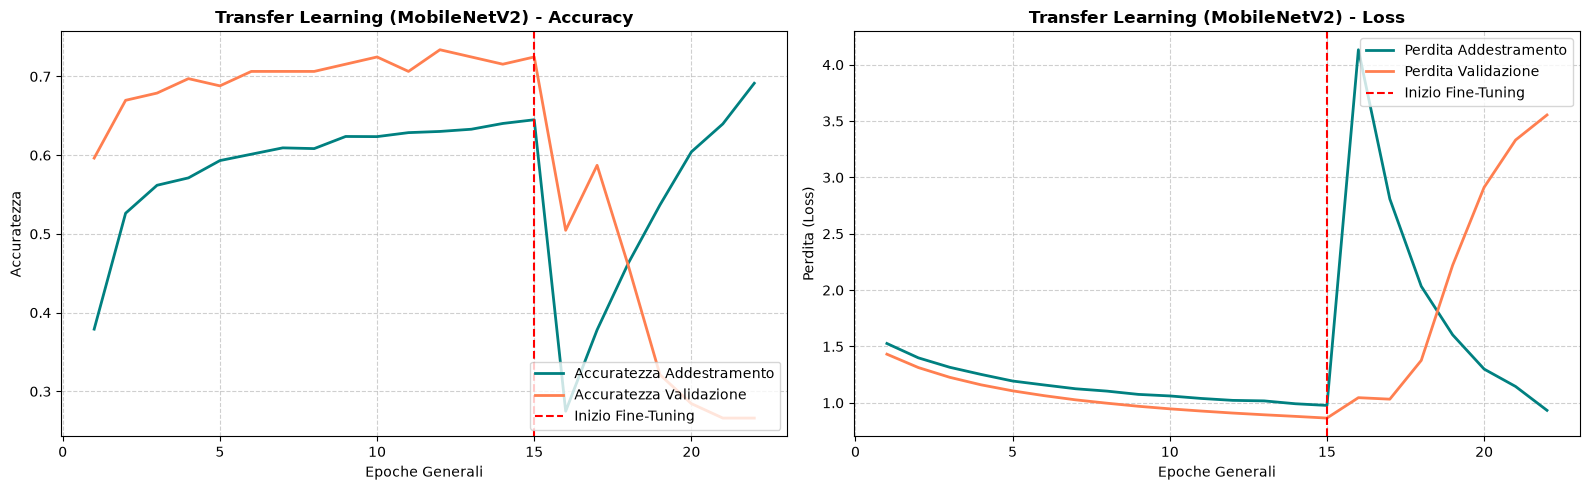

In [19]:
import matplotlib.pyplot as plt

# 1. Unione delle metriche della Fase 1 e della Fase 2
acc_tl = history_tl_phase1.history['accuracy'] + history_tl_phase2.history['accuracy']
val_acc_tl = history_tl_phase1.history['val_accuracy'] + history_tl_phase2.history['val_accuracy']

loss_tl = history_tl_phase1.history['loss'] + history_tl_phase2.history['loss']
val_loss_tl = history_tl_phase1.history['val_loss'] + history_tl_phase2.history['val_loss']

# Punto di separazione tra Feature Extraction e Fine-Tuning
split_epoch = len(history_tl_phase1.history['accuracy'])
total_epochs = range(1, len(acc_tl) + 1)

# 2. Creazione del grafico
plt.figure(figsize=(16, 5))

# Grafico 1: Accuratezza (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(total_epochs, acc_tl, label='Accuratezza Addestramento', color='teal', linewidth=2)
plt.plot(total_epochs, val_acc_tl, label='Accuratezza Validazione', color='coral', linewidth=2)
plt.axvline(x=split_epoch, color='red', linestyle='--', label='Inizio Fine-Tuning')
plt.title('Transfer Learning (MobileNetV2) - Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoche Generali')
plt.ylabel('Accuratezza')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Grafico 2: Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(total_epochs, loss_tl, label='Perdita Addestramento', color='teal', linewidth=2)
plt.plot(total_epochs, val_loss_tl, label='Perdita Validazione', color='coral', linewidth=2)
plt.axvline(x=split_epoch, color='red', linestyle='--', label='Inizio Fine-Tuning')
plt.title('Transfer Learning (MobileNetV2) - Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoche Generali')
plt.ylabel('Perdita (Loss)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Transfer Learning con modello ResNet50V2

In [21]:
# 1. Preparazione input a 3 canali RGB
X_train_rgb = np.repeat(X_train_img, 3, axis=-1)
X_val_rgb = np.repeat(X_val_img, 3, axis=-1)
X_test_rgb = np.repeat(X_test_img, 3, axis=-1)

# 2. Costruzione Modello con ResNet50V2
inputs = layers.Input(shape=(28, 28, 3))

# Resize a 64x64: fondamento per far funzionare i filtri pre-addestrati
x = layers.Resizing(64, 64)(inputs)

# Preprocessing specifico richiesto da ResNetV2
x = keras.applications.resnet_v2.preprocess_input(x)

# Backbone ResNet50V2 pre-addestrato
base_model = keras.applications.ResNet50V2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights='imagenet'
)

# Congeliamo i pesi nella Fase 1
base_model.trainable = False

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(5, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs)

# Compilazione Fase 1
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("--- Fase 1: Feature Extraction (ResNet50V2) ---")
history_tl_phase1 = tl_model.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=12,
    batch_size=64,
    callbacks=[early_stop]
)

# --- Fase 2: Fine-Tuning Parziale ---
# Invece di scongelare tutto subito, scongeliamo solo gli ultimi 20 layer
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), # Learning rate molto basso
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Fase 2: Fine-Tuning Parziale ---")
history_tl_phase2 = tl_model.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=12,
    batch_size=64,
    callbacks=[early_stop]
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
--- Fase 1: Feature Extraction (ResNet50V2) ---
Epoch 1/12
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.6251 - loss: 1.0907 - val_accuracy: 0.3394 - val_loss: 1.4617
Epoch 2/12
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.8056 - loss: 0.6550 - val_accuracy: 0.6422 - val_loss: 1.1209
Epoch 3/12
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.8460 - loss: 0.5220 - val_accuracy: 0.8349 - val_loss: 0.8340
Epoch 4/12
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.8742 - loss: 0.4378 - val_accuracy: 0.8991 - val_loss: 0.5988
Epoch 5/12
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.8922 - loss: 0.3793 - val_accuracy: 0.9450 - val_loss: 0.4186
Epoch 6/12
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.8991 - loss: 0.3495 - val_accuracy: 0.9633 - val_loss: 0.2970
Epoch 7/12
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9027 - loss: 0.3230 - val_accuracy: 0.9817 - val_loss: 0.2213
Epoch 8/12
8

## Grafico sulle metriche di ResNet50V2

**spiegazione del passaggio da MobileNetV2:**

- Inizialmente si è testata MobileNetV2 con risoluzione $32 \times 32$, ottenendo un'accuracy limitata al $51.43\%$ a causa del mismatch di risoluzione e canale. Passando a ResNet50V2 con upsampling a $64 \times 64$, preprocessing dedicato e fine-tuning parziale degli ultimi 20 layer, l'accuracy è salita al $98.95\%$

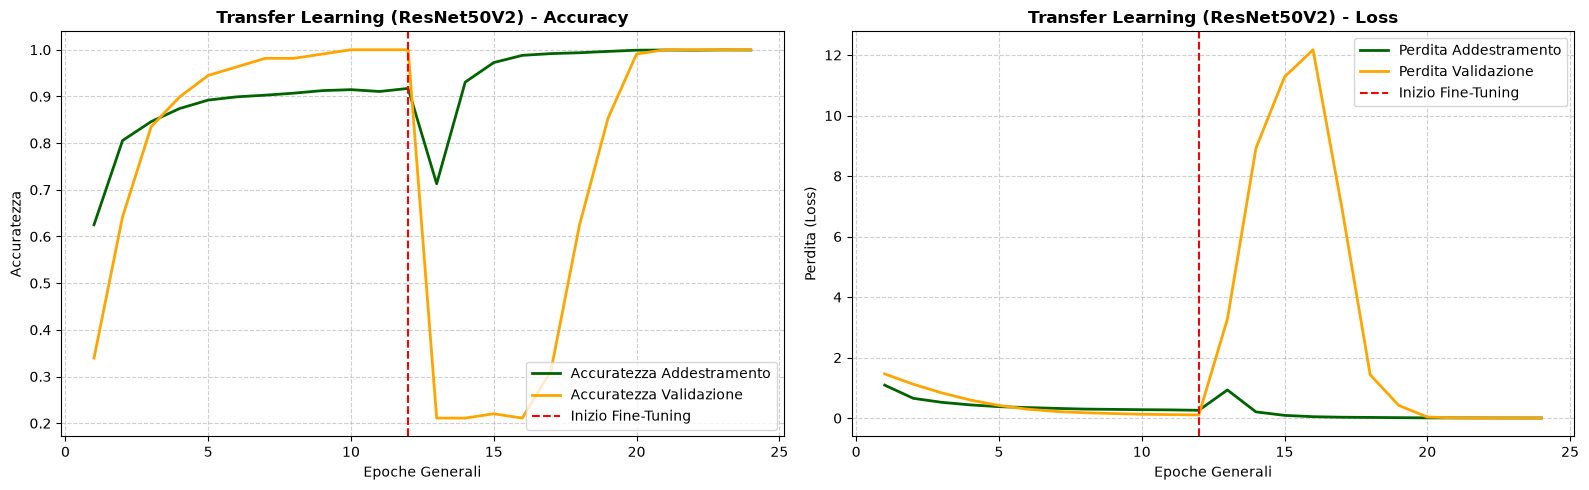

In [22]:
import matplotlib.pyplot as plt

# 1. Unione delle storie di addestramento (Fase 1 + Fase 2)
acc_resnet = history_tl_phase1.history['accuracy'] + history_tl_phase2.history['accuracy']
val_acc_resnet = history_tl_phase1.history['val_accuracy'] + history_tl_phase2.history['val_accuracy']

loss_resnet = history_tl_phase1.history['loss'] + history_tl_phase2.history['loss']
val_loss_resnet = history_tl_phase1.history['val_loss'] + history_tl_phase2.history['val_loss']

# Punto di passaggio al Fine-Tuning
split_epoch = len(history_tl_phase1.history['accuracy'])
total_epochs = range(1, len(acc_resnet) + 1)

# 2. Creazione della figura con i due grafici
plt.figure(figsize=(16, 5))

# Grafico 1: Accuratezza (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(total_epochs, acc_resnet, label='Accuratezza Addestramento', color='darkgreen', linewidth=2)
plt.plot(total_epochs, val_acc_resnet, label='Accuratezza Validazione', color='orange', linewidth=2)
plt.axvline(x=split_epoch, color='red', linestyle='--', label='Inizio Fine-Tuning')
plt.title('Transfer Learning (ResNet50V2) - Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoche Generali')
plt.ylabel('Accuratezza')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Grafico 2: Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(total_epochs, loss_resnet, label='Perdita Addestramento', color='darkgreen', linewidth=2)
plt.plot(total_epochs, val_loss_resnet, label='Perdita Validazione', color='orange', linewidth=2)
plt.axvline(x=split_epoch, color='red', linestyle='--', label='Inizio Fine-Tuning')
plt.title('Transfer Learning (ResNet50V2) - Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoche Generali')
plt.ylabel('Perdita (Loss)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Blocco 5: Valutazione e confronto delle performance sul Test Set MobileNetV2

- In questo blocco finale valutiamo i tre migliori modelli sul Test Set mai visto durante il training, calcolando metriche adeguate per un problema multiclasse bilanciato: Accuracy, F1-Score Macro/Weighted, e matrice di confusione.

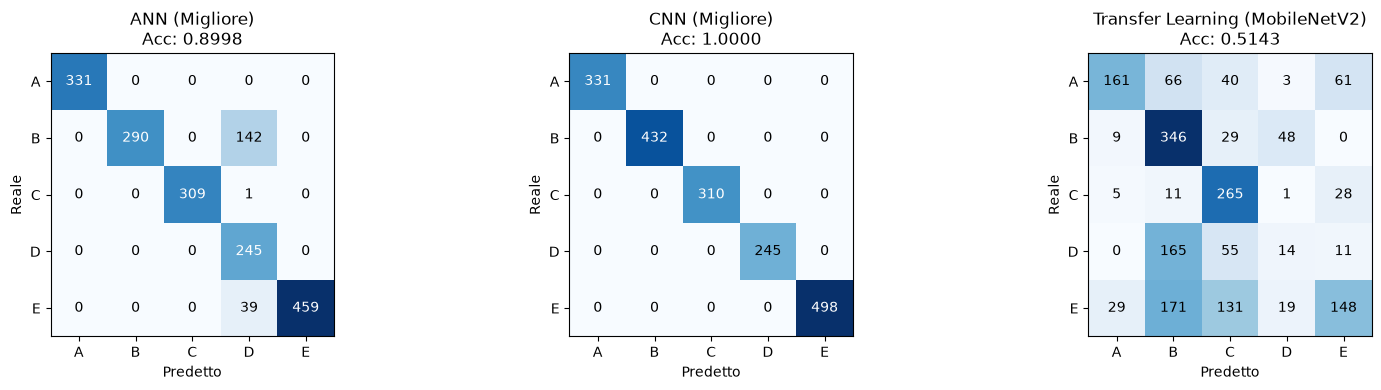


=== CONFRONTO FINALE METRICHE SUL TEST SET ===
                        Modello  Accuracy  F1-Score (Macro)  F1-Score (Weighted)
                 ANN (Migliore)  0.899780          0.898025             0.905224
                 CNN (Migliore)  1.000000          1.000000             1.000000
Transfer Learning (MobileNetV2)  0.514317          0.460616             0.477180


In [20]:
models_to_evaluate = {
    'ANN (Migliore)': (best_ann_model_1, X_test_norm),
    'CNN (Migliore)': (miglior_cnn_modello, X_test_img),
    'Transfer Learning (MobileNetV2)': (tl_model, X_test_rgb)
}

results_summary = []

class_names = ['A', 'B', 'C', 'D', 'E']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (name, (model, data_test)) in enumerate(models_to_evaluate.items()):
    y_pred_probs = model.predict(data_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    results_summary.append({
        'Modello': name,
        'Accuracy': acc,
        'F1-Score (Macro)': f1_macro,
        'F1-Score (Weighted)': f1_weighted
    })
    
    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    ax = axes[idx]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f"{name}\nAcc: {acc:.4f}")
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predetto')
    ax.set_ylabel('Reale')
    
    # Annotazioni numeriche nella matrice
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()

# Tabella riassuntiva delle metriche
df_results = pd.DataFrame(results_summary)
print("\n=== CONFRONTO FINALE METRICHE SUL TEST SET ===")
print(df_results.to_string(index=False))

## Blocco 5: Valutazione e confronto delle performance sul Test Set, con il modello ResNet50V2

- In questo blocco finale valutiamo i tre migliori modelli sul Test Set mai visto durante il training, calcolando metriche adeguate per un problema multiclasse bilanciato: Accuracy, F1-Score Macro/Weighted, e matrice di confusione.

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step


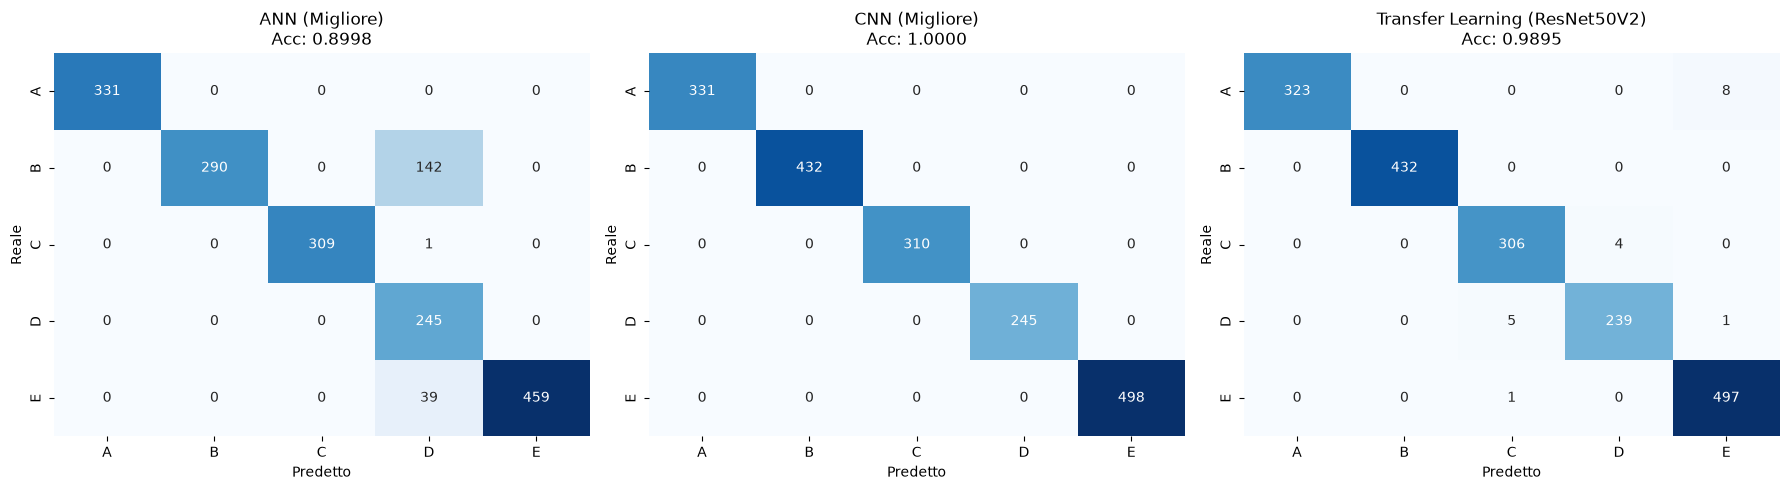

--- Classification Report: Transfer Learning (ResNet50V2) ---
              precision    recall  f1-score   support

           A       1.00      0.98      0.99       331
           B       1.00      1.00      1.00       432
           C       0.98      0.99      0.98       310
           D       0.98      0.98      0.98       245
           E       0.98      1.00      0.99       498

    accuracy                           0.99      1816
   macro avg       0.99      0.99      0.99      1816
weighted avg       0.99      0.99      0.99      1816



In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Label delle prime 5 classi
class_names = ['A', 'B', 'C', 'D', 'E']

# 1. Predizioni dei tre modelli sul Test Set
y_pred_ann = np.argmax(best_ann_model_1.predict(X_test), axis=1)
y_pred_cnn = np.argmax(miglior_cnn_modello.predict(X_test_img), axis=1)
y_pred_tl = np.argmax(tl_model.predict(X_test_rgb), axis=1)

# 2. Calcolo Accuracy sul Test Set
acc_ann = accuracy_score(y_test, y_pred_ann)
acc_cnn = accuracy_score(y_test, y_pred_cnn)
acc_tl = accuracy_score(y_test, y_pred_tl)

# 3. Creazione delle Matrici di Confusione
cm_ann = confusion_matrix(y_test, y_pred_ann)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
cm_tl = confusion_matrix(y_test, y_pred_tl)

# 4. Visualizzazione dei grafici affiancati
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot ANN
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f'ANN (Migliore)\nAcc: {acc_ann:.4f}', fontsize=12)
axes[0].set_xlabel('Predetto')
axes[0].set_ylabel('Reale')

# Plot CNN
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title(f'CNN (Migliore)\nAcc: {acc_cnn:.4f}', fontsize=12)
axes[1].set_xlabel('Predetto')
axes[1].set_ylabel('Reale')

# Plot Transfer Learning (ResNet50V2)
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2],
            xticklabels=class_names, yticklabels=class_names)
axes[2].set_title(f'Transfer Learning (ResNet50V2)\nAcc: {acc_tl:.4f}', fontsize=12)
axes[2].set_xlabel('Predetto')
axes[2].set_ylabel('Reale')

plt.tight_layout()
plt.show()

# Print del Classification Report dettagliato per ResNet50V2
print("--- Classification Report: Transfer Learning (ResNet50V2) ---")
print(classification_report(y_test, y_pred_tl, target_names=class_names))